# 06 · Análisis por jugador y equipo

**Objetivo.** Convertir el xG por disparo en insights agregados: xG por equipo y jugador, goles reales, y la diferencia **goles − xG** (sobre/infra-rendimiento en la finalización), además de mapas de disparos y de calor.

In [1]:
# Bootstrap: hace importable el paquete `xg` desde notebooks/ (src layout)
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == 'notebooks') else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from xg import config, features, models, analysis, visualization
from xg import data as data_loader
from xg.models import evaluation, statistics
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
config.ensure_dirs()
np.random.seed(config.RANDOM_STATE)
print('Proyecto:', config.PROJECT_ROOT.name)

Proyecto: TFM_xG_MachineLearning


In [2]:
raw, source = data_loader.build_shots_dataframe(source='auto')
feat = features.engineer_features(raw)
best_name = evaluation.evaluate_models_cv(
    {n: models.build_model_pipeline(n) for n in models.available_model_names()},
    *features.split_features_target(feat, drop_penalties=True)).index[0]
X, y = features.split_features_target(feat, drop_penalties=True)
scored = feat[feat['is_penalty']==0].reset_index(drop=True)
# Scoring HONESTO out-of-fold: cada disparo recibe un xG de un modelo que NO lo vio.
# Evita el optimismo de re-sustitución que comprimiría artificialmente goles - xG.
scored['xg_pred'] = evaluation.out_of_fold_scoring(
    models.build_model_pipeline, best_name, X, y, calibrate=True)
print('Disparos puntuados (OOF):', len(scored))

Disparos puntuados (OOF): 5606


## 6.1 Ranking de equipos por xG

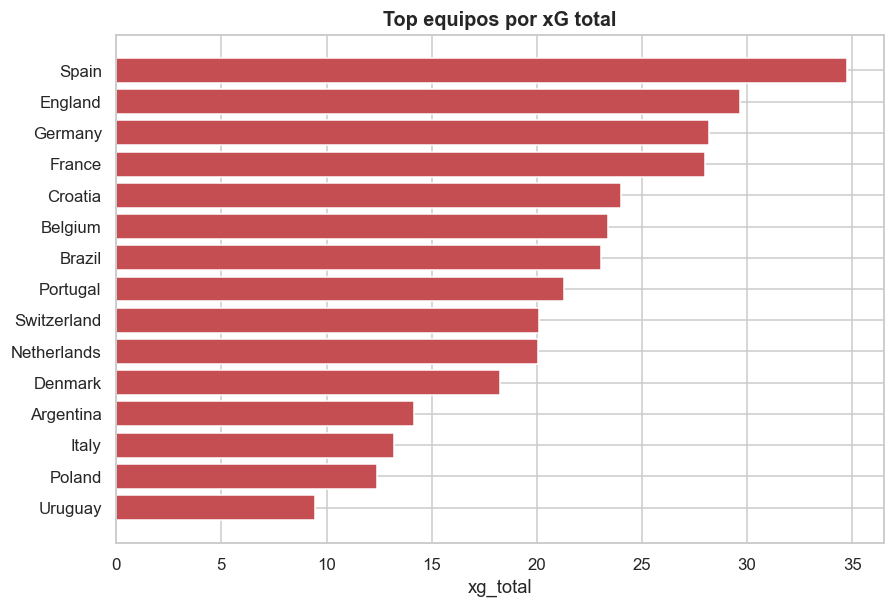

In [3]:
team_agg = analysis.aggregate_by(scored, 'team')
visualization.plot_ranking(team_agg, 'xg_total', 'team', 'Top equipos por xG total', save_as='ranking_teams_xg'); plt.show()
team_agg.head(10)

## 6.2 Mejores finalizadores (goles por encima de xG)
Filtramos por volumen mínimo de disparos para evitar ruido de muestras pequeñas.

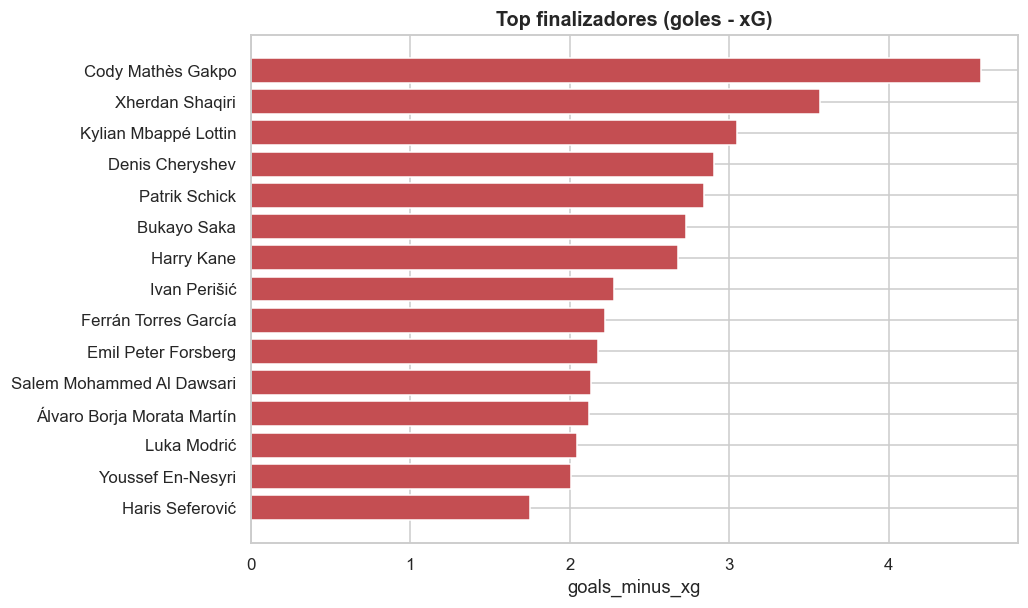

In [4]:
player_agg = analysis.aggregate_by(scored, 'player')
fin = analysis.overperformers(player_agg, min_shots=12, group_col='player')
visualization.plot_ranking(fin, 'goals_minus_xg', 'player', 'Top finalizadores (goles - xG)', save_as='ranking_finishers'); plt.show()
fin.head(10)

## 6.3 Mapa de disparos y mapa de calor de xG

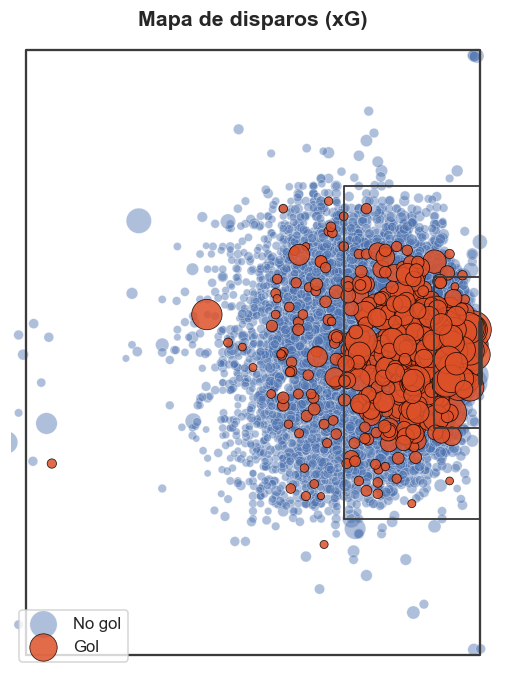

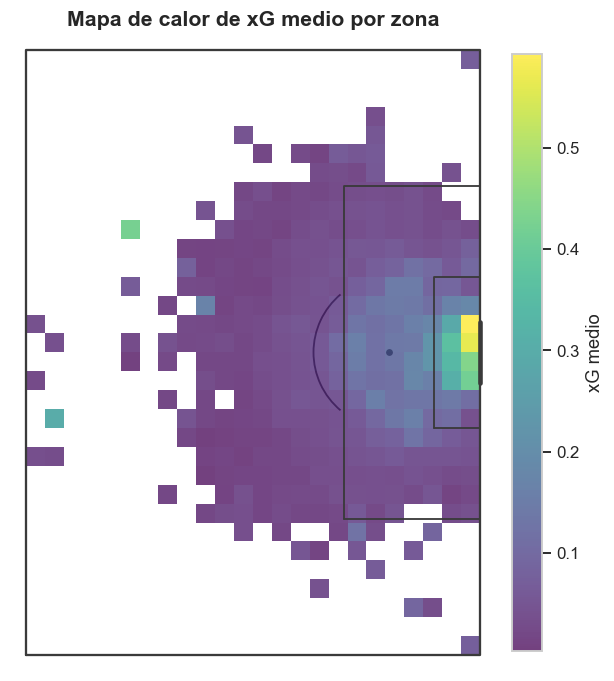

In [5]:
visualization.plot_shot_map(scored, 'xg_pred', save_as='shot_map'); plt.show()
visualization.plot_xg_heatmap(scored, 'xg_pred', save_as='xg_heatmap'); plt.show()

**Conclusión y trabajo futuro.**
El modelo permite cuantificar la calidad de las ocasiones por equipo y la eficacia finalizadora por jugador. Extensiones naturales: xG por secuencia (possession value), modelos por contexto (post-shot xG con datos de portería), incorporación de tracking data y validación temporal por temporadas.